# 00 - Raw Data EDA
1. Initial Exploratory Data Analysis (Raw Data)

This section examines the fundamental distributions and integrity of the source CEB export records and NASA POWER meteorological data prior to pipeline integration.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (13, 5), 'figure.dpi': 110})

MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# -- Paths ------------------------------------------------------
CEB_PATH = Path('../../processed/MASTER_DATASET_ALL_10TRANSFORMERS.csv')
NASA_API  = 'https://power.larc.nasa.gov/api/temporal/monthly/point'
LAT, LON  = 6.8514, 79.9211

df        = pd.read_csv(CEB_PATH)
solar     = df[df['HAS_SOLAR'] == 1].copy()
non_solar = df[df['HAS_SOLAR'] == 0].copy()

print(f"Total records        : {len(df):,}")
print(f"Solar accounts       : {solar['ACCOUNT_NO'].nunique()}")
print(f"Non-solar accounts   : {non_solar['ACCOUNT_NO'].nunique()}")
months = sorted(df['MONTH'].unique())
inverters = sorted(solar['INV_CAPACITY'].unique())

print("Months covered      :", ", ".join(map(str, months)))
print("Inverter sizes (kW) :", ", ".join(map(str, inverters)))
df.head()

Total records        : 8,184
Solar accounts       : 224
Non-solar accounts   : 458
Months covered      : 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12
Inverter sizes (kW) : 2.8, 3.0, 3.3, 4.0, 4.2, 5.0, 6.0, 7.0, 8.0, 10.0, 15.0, 17.0, 20.0, 40.0


,TRANSFORMER_CODE,TRANSFORMER_LAT,TRANSFORMER_LON,ACCOUNT_NO,CUSTOMER_LAT,CUSTOMER_LON,MONTH,YEAR,IMPORT_kWh,EXPORT_kWh,NET_CONSUMPTION_kWh,HAS_SOLAR,INV_CAPACITY,CAL_TARIFF,PHASE,DATA_QUALITY,DISTANCE_FROM_TF_M,SOURCE
0,AZ0001,6.8514,79.9211,703376102,6.851436,79.92136,1,2025,129.77,0.0,129.77,0,0.0,D1,SP,SYNTHETIC,28.95936,REAL
1,AZ0001,6.8514,79.9211,703376102,6.851436,79.92136,2,2025,117.56,0.0,117.56,0,0.0,D1,SP,SYNTHETIC,28.95936,REAL
2,AZ0001,6.8514,79.9211,703376102,6.851436,79.92136,3,2025,141.75,0.0,141.75,0,0.0,D1,SP,SYNTHETIC,28.95936,REAL
3,AZ0001,6.8514,79.9211,703376102,6.851436,79.92136,4,2025,164.61,0.0,164.61,0,0.0,D1,SP,SYNTHETIC,28.95936,REAL
4,AZ0001,6.8514,79.9211,703376102,6.851436,79.92136,5,2025,154.19,0.0,154.19,0,0.0,D1,SP,SYNTHETIC,28.95936,REAL


## 1. Schema & Data Quality - REAL vs SYNTHETIC

Data quality breakdown:
  SYNTHETIC   :  7,737  (94.5%)
  REAL        :    436  (5.3%)
  FILLED      :     11  (0.1%)


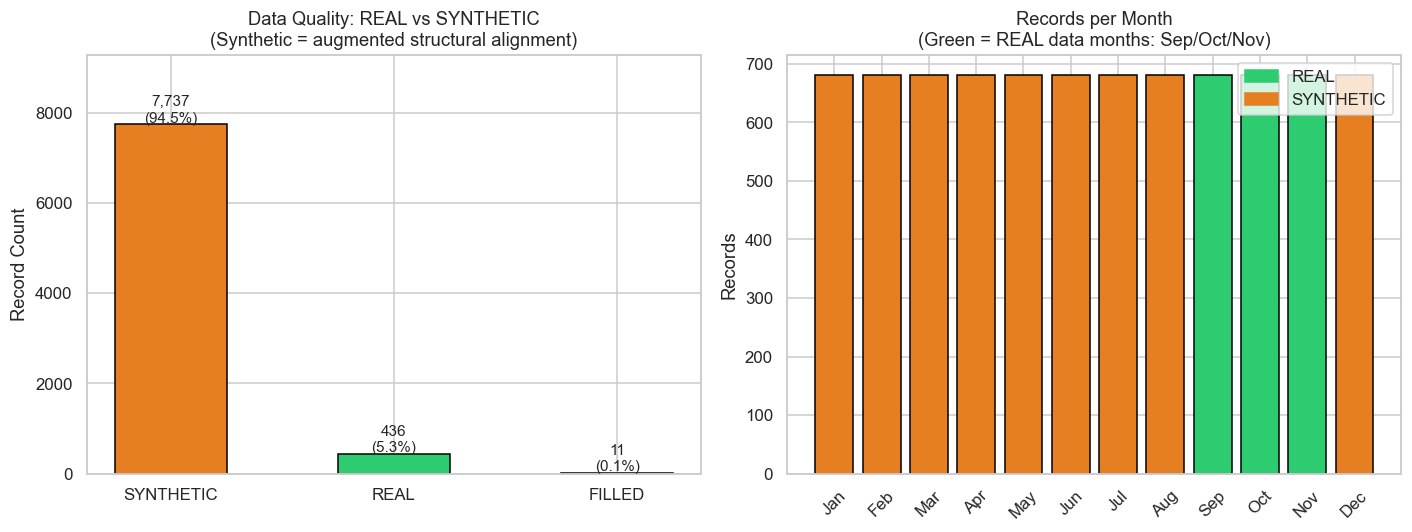

In [10]:
quality = df['DATA_QUALITY'].value_counts()
print("Data quality breakdown:")
for q, n in quality.items():
    print(f"  {q:<12}: {n:>6,}  ({n/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart: REAL vs SYNTHETIC
colors = ['#2ecc71' if q == 'REAL' else '#e67e22' for q in quality.index]
axes[0].bar(quality.index, quality.values, color=colors, edgecolor='black', width=0.5)
for i, (q, n) in enumerate(quality.items()):
    axes[0].text(i, n + 50, f"{n:,}\n({n/len(df)*100:.1f}%)", ha='center', fontsize=10)
axes[0].set_ylabel('Record Count')
axes[0].set_title('Data Quality: REAL vs SYNTHETIC\n(Synthetic = augmented structural alignment)')
axes[0].set_ylim(0, quality.max() * 1.2)

# REAL months highlighted on monthly record count
monthly_counts = df.groupby(['MONTH','DATA_QUALITY']).size().unstack(fill_value=0)
real_m    = [9, 10, 11]
bar_cols  = ['#2ecc71' if m in real_m else '#e67e22' for m in monthly_counts.index]
axes[1].bar(monthly_counts.index, monthly_counts.sum(axis=1), color=bar_cols, edgecolor='black')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(MONTHS, rotation=45)
axes[1].set_ylabel('Records')
axes[1].set_title('Records per Month\n(Green = REAL data months: Sep/Oct/Nov)')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='#2ecc71', label='REAL'), Patch(color='#e67e22', label='SYNTHETIC')])

plt.tight_layout()
plt.savefig('figures/00_data_quality.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Export Distribution — Justifying IQR Outlier Removal

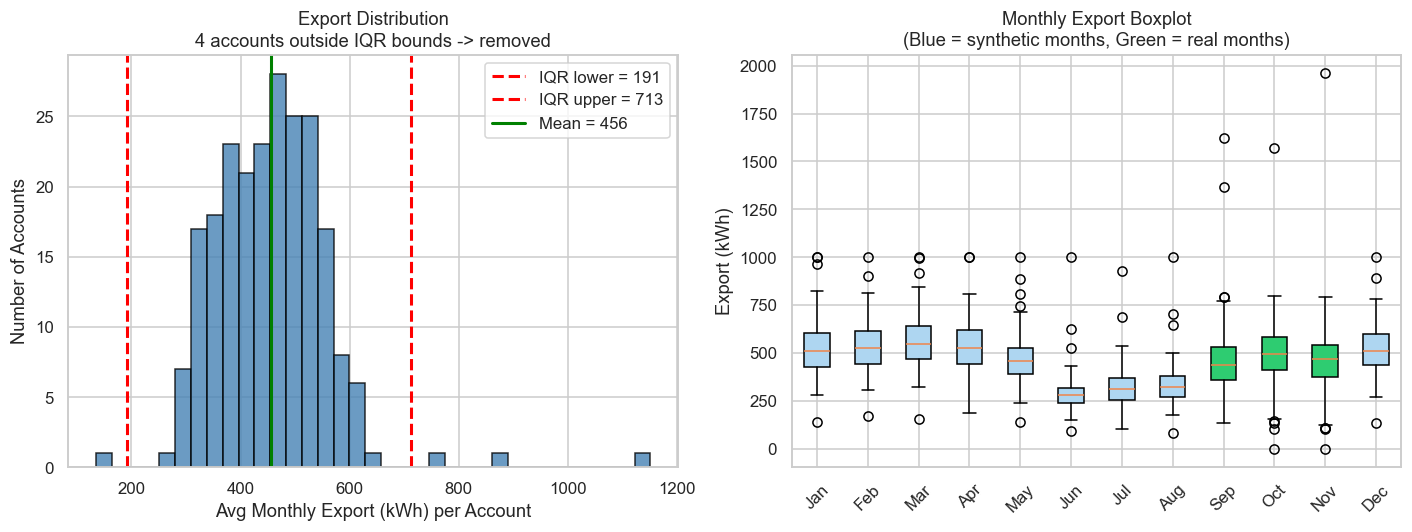

IQR bounds  : [191, 713] kWh
Outlier accounts: 4 (1.8%)
These accounts are removed in data_pipeline.py Step 3.


In [11]:
account_avg = solar.groupby('ACCOUNT_NO')['EXPORT_kWh'].mean()

Q1  = account_avg.quantile(0.25)
Q3  = account_avg.quantile(0.75)
IQR = Q3 - Q1
lo  = Q1 - 1.5 * IQR
hi  = Q3 + 1.5 * IQR
outliers = account_avg[(account_avg < lo) | (account_avg > hi)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram with IQR bounds
axes[0].hist(account_avg, bins=35, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(lo, color='red',    linestyle='--', linewidth=2, label=f'IQR lower = {lo:.0f}')
axes[0].axvline(hi, color='red',    linestyle='--', linewidth=2, label=f'IQR upper = {hi:.0f}')
axes[0].axvline(account_avg.mean(), color='green', linestyle='-', linewidth=2,
                label=f'Mean = {account_avg.mean():.0f}')
axes[0].set_xlabel('Avg Monthly Export (kWh) per Account')
axes[0].set_ylabel('Number of Accounts')
axes[0].set_title(f'Export Distribution\n{len(outliers)} accounts outside IQR bounds -> removed')
axes[0].legend()

# Monthly distribution — boxplot
monthly_data = [solar[solar['MONTH']==m]['EXPORT_kWh'].values for m in range(1,13)]
bp = axes[1].boxplot(monthly_data, labels=MONTHS, patch_artist=True)
for patch, m in zip(bp['boxes'], range(1,13)):
    patch.set_facecolor('#2ecc71' if m in [9,10,11] else '#aed6f1')
axes[1].set_ylabel('Export (kWh)')
axes[1].set_title('Monthly Export Boxplot\n(Blue = synthetic months, Green = real months)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('figures/00_export_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"IQR bounds  : [{lo:.0f}, {hi:.0f}] kWh")
print(f"Outlier accounts: {len(outliers)} ({len(outliers)/account_avg.nunique()*100:.1f}%)")
print("These accounts are removed in data_pipeline.py Step 3.")

## 3. Monthly Generation Pattern

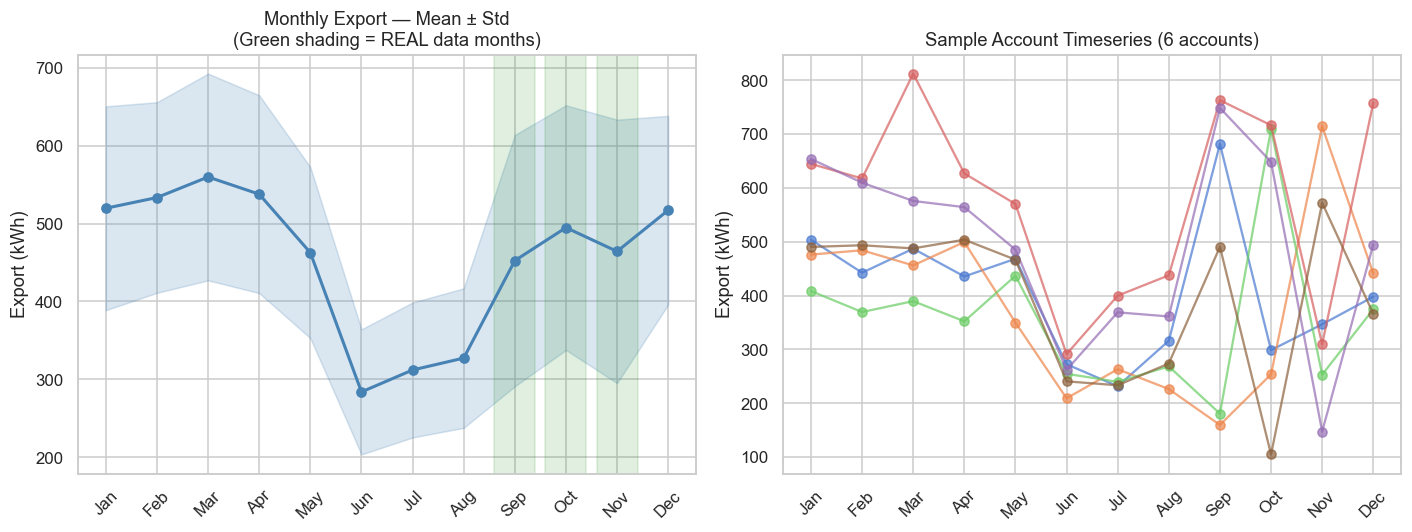

Peak month   : Mar
Trough month : Jun


In [12]:
monthly = solar.groupby('MONTH')['EXPORT_kWh'].agg(['mean','std','min','max']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Mean ± std line
axes[0].plot(monthly['MONTH'], monthly['mean'], marker='o', linewidth=2, color='steelblue')
axes[0].fill_between(monthly['MONTH'],
                     monthly['mean'] - monthly['std'],
                     monthly['mean'] + monthly['std'], alpha=0.2, color='steelblue')
for m in [9,10,11]:
    axes[0].axvspan(m-0.4, m+0.4, alpha=0.12, color='green')
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(MONTHS, rotation=45)
axes[0].set_ylabel('Export (kWh)'); axes[0].set_title('Monthly Export — Mean ± Std\n(Green shading = REAL data months)')

# Sample account timeseries
sample = solar['ACCOUNT_NO'].unique()[:6]
for acc in sample:
    d = solar[solar['ACCOUNT_NO']==acc].sort_values('MONTH')
    axes[1].plot(d['MONTH'], d['EXPORT_kWh'], marker='o', alpha=0.7, linewidth=1.5)
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(MONTHS, rotation=45)
axes[1].set_ylabel('Export (kWh)'); axes[1].set_title('Sample Account Timeseries (6 accounts)')

plt.tight_layout()
plt.savefig('figures/00_monthly_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

peak  = MONTHS[monthly.set_index('MONTH')['mean'].idxmax()-1]
trough= MONTHS[monthly.set_index('MONTH')['mean'].idxmin()-1]
print(f"Peak month   : {peak}")
print(f"Trough month : {trough}")

## 4. Inverter Capacity vs Export — Motivating Efficiency Normalisation

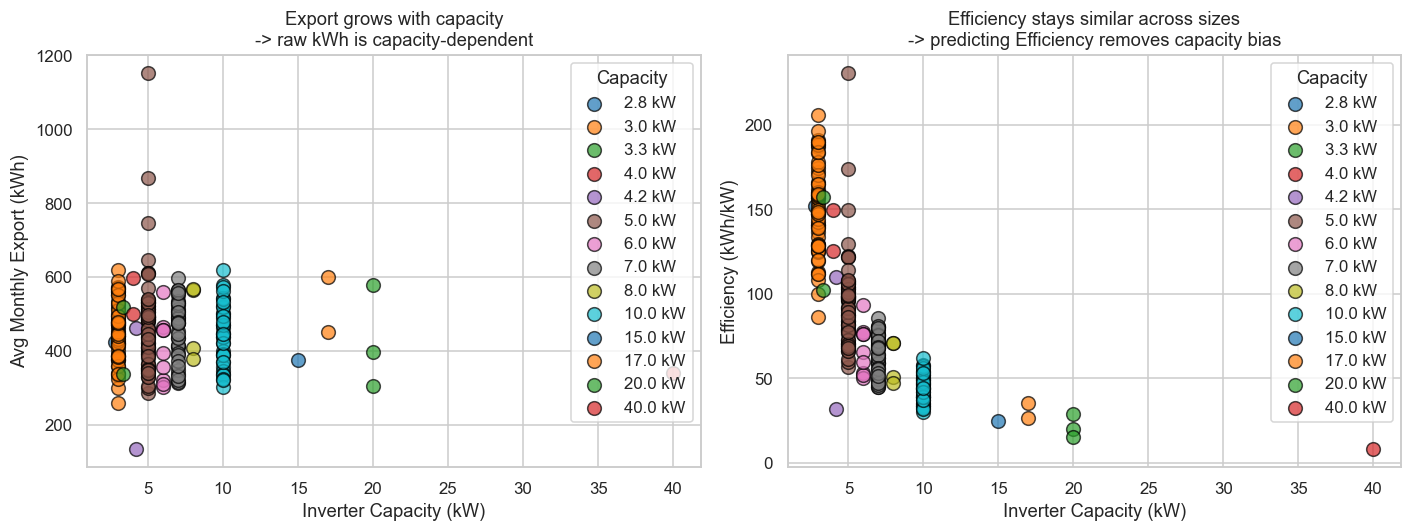

Correlation: INV_CAPACITY vs EXPORT_kWh  = -0.062  (capacity-dependent)
Correlation: INV_CAPACITY vs Efficiency  = -0.685  (capacity-independent ✓)


In [13]:
account_data = solar.groupby('ACCOUNT_NO').agg(
    EXPORT_kWh=('EXPORT_kWh','mean'),
    INV_CAPACITY=('INV_CAPACITY','first')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

caps    = sorted(account_data['INV_CAPACITY'].unique())
palette = sns.color_palette('tab10', len(caps))
for cap, col in zip(caps, palette):
    d = account_data[account_data['INV_CAPACITY']==cap]
    axes[0].scatter(d['INV_CAPACITY'], d['EXPORT_kWh'], s=80, alpha=0.7,
                    color=col, edgecolor='black', label=f'{cap} kW')
axes[0].set_xlabel('Inverter Capacity (kW)'); axes[0].set_ylabel('Avg Monthly Export (kWh)')
axes[0].set_title('Export grows with capacity\n-> raw kWh is capacity-dependent')
axes[0].legend(title='Capacity')

# Efficiency (kWh/kW) stays flat
account_data['Efficiency'] = account_data['EXPORT_kWh'] / account_data['INV_CAPACITY']
for cap, col in zip(caps, palette):
    d = account_data[account_data['INV_CAPACITY']==cap]
    axes[1].scatter(d['INV_CAPACITY'], d['Efficiency'], s=80, alpha=0.7,
                    color=col, edgecolor='black', label=f'{cap} kW')
axes[1].set_xlabel('Inverter Capacity (kW)'); axes[1].set_ylabel('Efficiency (kWh/kW)')
axes[1].set_title('Efficiency stays similar across sizes\n-> predicting Efficiency removes capacity bias')
axes[1].legend(title='Capacity')

plt.tight_layout()
plt.savefig('figures/00_capacity_vs_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

corr_raw = account_data[['INV_CAPACITY','EXPORT_kWh']].corr().iloc[0,1]
corr_eff = account_data[['INV_CAPACITY','Efficiency']].corr().iloc[0,1]
print(f"Correlation: INV_CAPACITY vs EXPORT_kWh  = {corr_raw:.3f}  (capacity-dependent)")
print(f"Correlation: INV_CAPACITY vs Efficiency  = {corr_eff:.3f}  (capacity-independent ✓)")

## 5. Solar vs Non-Solar Import Comparison

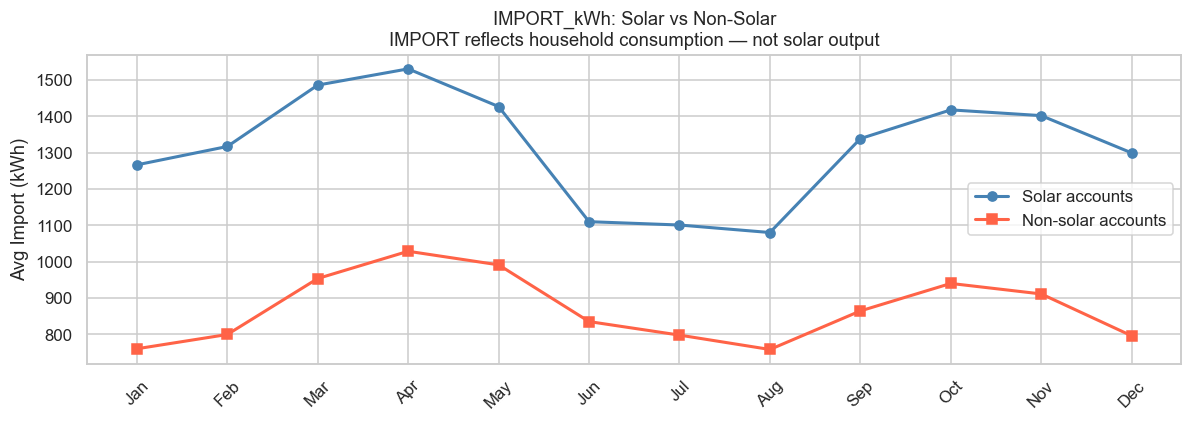

Solar avg import     : 1314.8 kWh
Non-solar avg import : 869.8 kWh

Conclusion: IMPORT_kWh is a household behaviour signal, not solar generation.
It is excluded from model features (see config.yaml cols_to_drop).


In [14]:
mi_solar    = solar.groupby('MONTH')['IMPORT_kWh'].mean()
mi_nonsolar = non_solar.groupby('MONTH')['IMPORT_kWh'].mean()

plt.figure(figsize=(11, 4))
plt.plot(mi_solar.index, mi_solar.values, marker='o', linewidth=2,
         label='Solar accounts', color='steelblue')
plt.plot(mi_nonsolar.index, mi_nonsolar.values, marker='s', linewidth=2,
         label='Non-solar accounts', color='tomato')
plt.xticks(range(1,13), MONTHS, rotation=45)
plt.ylabel('Avg Import (kWh)'); plt.legend()
plt.title('IMPORT_kWh: Solar vs Non-Solar\nIMPORT reflects household consumption — not solar output')
plt.tight_layout()
plt.savefig('figures/00_import_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Solar avg import     : {solar['IMPORT_kWh'].mean():.1f} kWh")
print(f"Non-solar avg import : {non_solar['IMPORT_kWh'].mean():.1f} kWh")
print("\nConclusion: IMPORT_kWh is a household behaviour signal, not solar generation.")
print("It is excluded from model features (see config.yaml cols_to_drop).")

## 6. NASA POWER Weather Trends — Sri Lanka Seasonality

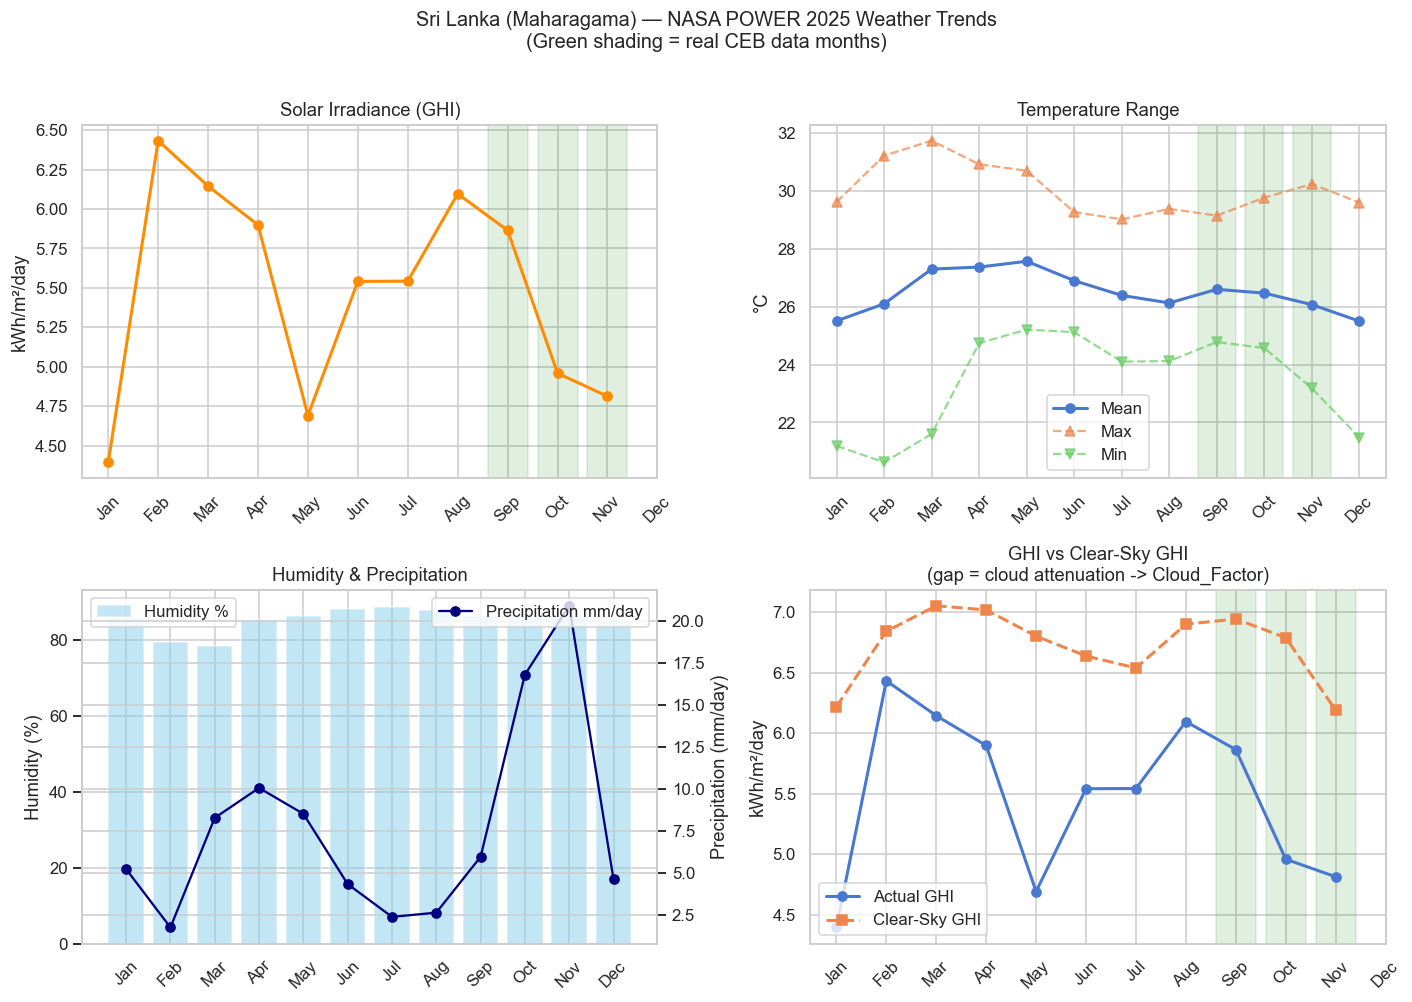

In [15]:
PARAMS = {
    'ALLSKY_SFC_SW_DWN': 'Solar_Irradiance_GHI',
    'T2M': 'Temperature', 'T2M_MAX': 'Max_Temperature',
    'T2M_MIN': 'Min_Temperature', 'RH2M': 'Humidity',
    'PRECTOTCORR': 'Precipitation', 'WS10M': 'Wind_Speed',
    'CLRSKY_SFC_SW_DWN': 'Clear_Sky_GHI',
}
params_str = ','.join(PARAMS.keys())
url = (f"{NASA_API}?parameters={params_str}&community=RE"
       f"&longitude={LON}&latitude={LAT}&start=2025&end=2025&format=JSON")
data   = requests.get(url, timeout=60).json()
params = data['properties']['parameter']
weather = pd.DataFrame([{
    'Month': m,
    **{label: (params[key].get(f'2025{m:02d}', -999) if params[key].get(f'2025{m:02d}', -999) != -999 else None)
       for key, label in PARAMS.items()}
} for m in range(1, 13)])

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
real_m = [9, 10, 11]

def shade(ax):
    for m in real_m:
        ax.axvspan(m-0.4, m+0.4, alpha=0.12, color='green')

# GHI
ax = axes[0,0]
ax.plot(weather['Month'], weather['Solar_Irradiance_GHI'], marker='o', color='darkorange', linewidth=2)
shade(ax); ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTHS, rotation=45)
ax.set_ylabel('kWh/m²/day'); ax.set_title('Solar Irradiance (GHI)')

# Temperature
ax = axes[0,1]
ax.plot(weather['Month'], weather['Temperature'],     marker='o', label='Mean',  linewidth=2)
ax.plot(weather['Month'], weather['Max_Temperature'], marker='^', label='Max',   linestyle='--', alpha=0.7)
ax.plot(weather['Month'], weather['Min_Temperature'], marker='v', label='Min',   linestyle='--', alpha=0.7)
shade(ax); ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTHS, rotation=45)
ax.set_ylabel('°C'); ax.set_title('Temperature Range'); ax.legend()

# Humidity & Precipitation
ax = axes[1,0]
ax2 = ax.twinx()
ax.bar(weather['Month'], weather['Humidity'], alpha=0.5, color='skyblue', label='Humidity %')
ax2.plot(weather['Month'], weather['Precipitation'], marker='o', color='navy', label='Precipitation mm/day')
ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTHS, rotation=45)
ax.set_ylabel('Humidity (%)'); ax2.set_ylabel('Precipitation (mm/day)')
ax.set_title('Humidity & Precipitation')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')

# GHI vs Clear Sky
ax = axes[1,1]
ax.plot(weather['Month'], weather['Solar_Irradiance_GHI'], marker='o', label='Actual GHI',    linewidth=2)
ax.plot(weather['Month'], weather['Clear_Sky_GHI'],        marker='s', label='Clear-Sky GHI', linestyle='--', linewidth=2)
shade(ax); ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTHS, rotation=45)
ax.set_ylabel('kWh/m²/day'); ax.set_title('GHI vs Clear-Sky GHI\n(gap = cloud attenuation -> Cloud_Factor)')
ax.legend()

plt.suptitle('Sri Lanka (Maharagama) — NASA POWER 2025 Weather Trends\n(Green shading = real CEB data months)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/00_weather_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Missing GHI Check — Justifying Imputation

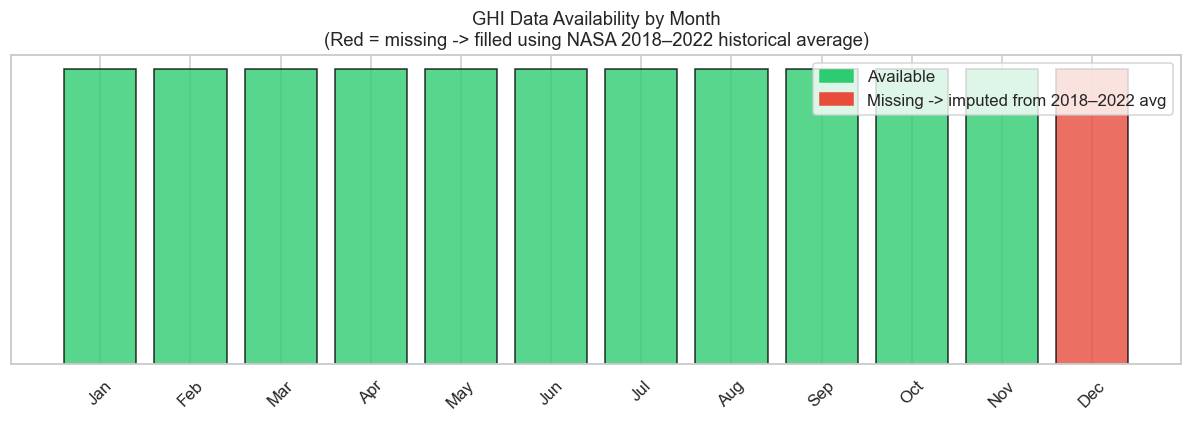

Missing GHI months: ['Dec']
Fix: src/preprocessing/missing.py fetches NASA 2018–2022 monthly averages.
     Imputed values are treated as synthetic — real-data correlation
     analysis in Notebook 01 uses Sep/Oct/Nov only.


In [16]:
missing_by_month = weather.set_index('Month')[['Solar_Irradiance_GHI','Clear_Sky_GHI']].isna().sum(axis=1)

fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#e74c3c' if missing_by_month.get(m, 0) > 0 else '#2ecc71' for m in range(1,13)]
ax.bar(range(1,13), [1]*12, color=colors, edgecolor='black', alpha=0.8)
ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTHS, rotation=45)
ax.set_yticks([])
ax.set_title('GHI Data Availability by Month\n(Red = missing -> filled using NASA 2018–2022 historical average)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#2ecc71', label='Available'),
                   Patch(color='#e74c3c', label='Missing -> imputed from 2018–2022 avg')])
plt.tight_layout()
plt.savefig('figures/00_missing_ghi.png', dpi=150, bbox_inches='tight')
plt.show()

missing_months = missing_by_month[missing_by_month > 0].index.tolist()
print(f"Missing GHI months: {[MONTHS[m-1] for m in missing_months]}")
print("Fix: src/preprocessing/missing.py fetches NASA 2018–2022 monthly averages.")
print("     Imputed values are treated as synthetic — real-data correlation")
print("     analysis in Notebook 01 uses Sep/Oct/Nov only.")